In [1]:
import psi4
import numpy as np
import matplotlib.pyplot as plt

In [4]:
arr = np.arange(2, 10.2, 0.2)
expected_wb97x = np.array([
    -2.324611021, -2.329423344, -2.331832126, -2.332949232, -2.333411109,
    -2.333575346, -2.333618351, -2.333614925, -2.333595294, -2.333572272,
    -2.333551618, -2.333535048, -2.333523333, -2.333516144, -2.333511993,
    -2.333510247, -2.333509353, -2.333509533, -2.333509531, -2.333509913,
    -2.333509991, -2.333510161, -2.333510212, -2.333510238, -2.333510250,
    -2.333510228, -2.333510206, -2.333510175, -2.333510134, -2.333510089,
    -2.333510057, -2.333510043, -2.333510045, -2.333510054, -2.333510066,
    -2.333510077, -2.333510087, -2.333510095, -2.333510104, -2.333510113,
    -2.333510121
])

expected_wb97x_d = np.array([
    -2.333185629, -2.338301274, -2.340928338, -2.342192525, -2.342782655,
    -2.343063708, -2.343201138, -2.343264455, -2.343287184, -2.343288472,
    -2.343279997, -2.343268067, -2.343256596, -2.343247220, -2.343240039,
    -2.343235032, -2.343231377, -2.343229043, -2.343227168, -2.343225936,
    -2.343224817, -2.343224001, -2.343223260, -2.343222640, -2.343222126,
    -2.343221674, -2.343221302, -2.343220985, -2.343220709, -2.343220466,
    -2.343220265, -2.343220105, -2.343219981, -2.343219884, -2.343219807,
    -2.343219746, -2.343219696, -2.343219655, -2.343219621, -2.343219594,
    -2.343219572
])

expected_fci =  np.array([
    -2.318806517, -2.324008044, -2.326756512, -2.328139642, -2.328789567,
    -2.329073442, -2.329186564, -2.329223685, -2.329228808, -2.329222171,
    -2.329212725, -2.329203909, -2.329196615, -2.329190770, -2.329186085,
    -2.329182306, -2.329179254, -2.329176793, -2.329174811, -2.329173212,
    -2.329171915, -2.329170855, -2.329169984, -2.329169263, -2.329168665,
    -2.329168168, -2.329167755, -2.329167414, -2.329167132, -2.329166901,
    -2.329166713, -2.329166561, -2.329166439, -2.329166342, -2.329166265,
    -2.329166204, -2.329166156, -2.329166118, -2.329166088, -2.329166065,
    -2.329166047
])

In [5]:
import psi4
import numpy as np
import matplotlib.pyplot as plt

# Define the methods/levels of theory
#methods = [
#    'ccsd', 
#    'wb97x-d', 
#    'ccsd(t)', 
#    'fci'
#]

psi4_options = {
    "basis": "aug-cc-pvdz",
    "scf_type": "df",
    "e_convergence": 1e-10,
    "d_convergence": 1e-8,
    "dft_radial_points": 99,
    "dft_spherical_points": 302,
    "dft_pruning_scheme": "none"
}

psi4.set_options(psi4_options)

methods = [
    'wb97x-d', 
    'fci'
]
basis = 'aug-cc-pvdz'

# Initialize a dictionary to store lists of energies for each method
energy_data = {m: [] for m in methods}
distances = []

d_vals = arr #np.linspace(2.0, 8.0, 50) # Example range

for d in d_vals:
    # Update geometry for the current distance
    geom_string = f"""
    0 1
    H  -0.370000000  0.000000000  0.000000000
    H   0.370000000  0.000000000  0.000000000
    H  -0.370000000  0.000000000  {d}
    H   0.370000000  0.000000000  {d}
    symmetry c1
    nocom
    no_reorient
    """
    mol = psi4.geometry(geom_string)
    distances.append(d)
    
    for m in methods:
        print(f"Running {m}/{basis} at d = {d:.3f}")
        # Calculation call
        e = psi4.energy(f"{m}/{basis}")
        energy_data[m].append(e)

# 3. Define the Asymptote
# We use the last element index [-1] of the FCI list
fci_asymptote = energy_data['fci'][-1]

Running wb97x-d/aug-cc-pvdz at d = 2.000

Scratch directory: /tmp/
   => Libint2 <=

    Primary   basis highest AM E, G, H:  6, 6, 3
    Auxiliary basis highest AM E, G, H:  7, 7, 4
    Onebody   basis highest AM E, G, H:  -, -, -
    Solid Harmonics ordering:            Gaussian

*** tstart() called on CHEM9QDFT72ALT
*** at Mon Apr  6 16:43:33 2026

   => Loading Basis Set <=

    Name: AUG-CC-PVDZ
    Role: ORBITAL
    Keyword: BASIS
    atoms 1-4 entry H          line    40 file /Users/jfoley19/miniconda3/envs/psi4_new/share/psi4/basis/aug-cc-pvdz.gbs 

   => WB97X-D: Empirical Dispersion <=

    Chai and Head-Gordon Dispersion Correction
    Chai, J.-D.; Head-Gordon, M. (2010), J. Chem. Phys., 132: 6615-6620

        s6 =       1.000000


         ---------------------------------------------------------
                                   SCF
               by Justin Turney, Rob Parrish, Andy Simmonett
                          and Daniel G. A. Smith
                              

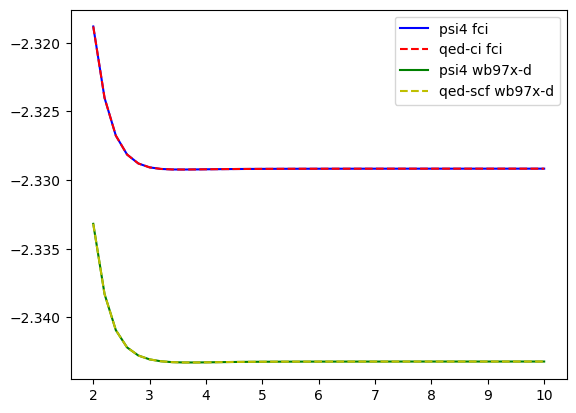

In [6]:
plt.plot(distances, energy_data['fci'], 'b-', label='psi4 fci')
plt.plot(arr, expected_fci, 'r--', label='qed-ci fci')
plt.plot(distances, energy_data['wb97x-d'], 'g-', label='psi4 wb97x-d')
plt.plot(arr, expected_wb97x_d, 'y--', label='qed-scf wb97x-d')
plt.legend()
plt.show()

In [ ]:
# 4. Shift all energies relative to E_FCI(r=8)
# We convert lists to numpy arrays to make subtraction easy
relative_energies = {}
for m in methods:
    relative_energies[m] = (np.array(energy_data[m]) - fci_asymptote) * 627.509 # Optional: Convert Hartree to kcal/mol

# 5. Plotting
plt.figure(figsize=(10, 7))

for m in methods:
    plt.plot(distances, relative_energies[m], lw=2, label=m.upper())

plt.axhline(0, color='black', linestyle='--', alpha=0.5, label='FCI Asymptote')
plt.xlabel('Distance $d$ (Å)')
plt.ylabel('Relative Energy (kcal/mol)')
plt.title('Potential Energy Surface Relative to FCI Dissociation Limit')
#plt.ylim(-2.5, 0.25) # Adjust limits to see the "well" more clearly
plt.legend()
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.show()

In [ ]:
for m in methods:
    #if m != 'wb97x-d':
    plt.plot(distances, energy_data[m], marker='o', label=m.upper())

plt.xlabel('Distance $d$ (Å)')
plt.ylabel('Energy (Hartree)')
plt.title('Potential Energy Surface Comparison')
plt.xlim(2.5,8)
plt.ylim(-2.3493,-2.3291)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import psi4
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup methods and range
methods = ['ccsd', 'wb97x-d', 'ccsd(t)', 'fci']
basis = 'cc-pvdz'
d_vals = np.linspace(2.0, 8.0, 50) # Scans out to 8.0 Angstroms

energy_data = {m: [] for m in methods}
distances = []

# 2. Run the scan
for d in d_vals:
    # H4 geometry configuration
    geom_string = f"""
    0 1
    H  -0.370000000  0.000000000  0.000000000
    H   0.370000000  0.000000000  0.000000000
    H  -0.370000000  0.000000000  {d}
    H   0.370000000  0.000000000  {d}
    unit angstrom
    padding 0
    symmetry c1
    """
    psi4.geometry(geom_string)
    distances.append(d)
    
    for m in methods:
        print(f"Calculating {m} at d = {d:.3f}")
        e = psi4.energy(f"{m}/{basis}")
        energy_data[m].append(e)

# 3. Define the Asymptote
# We use the last element index [-1] of the FCI list
fci_asymptote = energy_data['fci'][-1]



In [ ]:
# 4. Shift all energies relative to E_FCI(r=8)
# We convert lists to numpy arrays to make subtraction easy
relative_energies = {}
for m in methods:
    relative_energies[m] = (np.array(energy_data[m]) - fci_asymptote) * 627.509 # Optional: Convert Hartree to kcal/mol

# 5. Plotting
plt.figure(figsize=(10, 7))

for m in methods:
    plt.plot(distances, relative_energies[m], lw=2, label=m.upper())

plt.axhline(0, color='black', linestyle='--', alpha=0.5, label='FCI Asymptote')
plt.xlabel('Distance $d$ (Å)')
plt.ylabel('Relative Energy (kcal/mol)')
plt.title('Potential Energy Surface Relative to FCI Dissociation Limit')
plt.ylim(-150, 100) # Adjust limits to see the "well" more clearly
plt.legend()
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.show()